In [47]:
import os
import synth_reader as sr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from astropy.io import fits
from astropy.table import Table
import sys
import glob
from pathlib import Path
from numpy import savetxt
import matplotlib
from PyAstronomy import pyasl
from scipy.interpolate import interp1d
from astropy import units as u
from astropy.coordinates import SkyCoord
#install dustmaps from https://github.com/gregreen/dustmaps
from dustmaps.sfd import SFDQuery

from joblib import Parallel, delayed

import farsight

In [2]:
# ============================================================
# Catálogo básico de líneas de emisión ópticas en galaxias HII
# ============================================================
HII_LINE_CATALOG = [
    (3726.032, "[OII]", "3726.032"),
    (3728.815, "[OII]", "3728.815"),
    (3868.760, "[NeIII]", "3868.760"),
    (3889.064, "HeI+H8", "3889.064"),
    (3970.072, "Hepsilon", "3970.072"),
    (4101.734, "Hdelta", "4101.734"),
    (4340.472, "Hgamma", "4340.472"),
    (4363.210, "[OIII]", "4363.210"),
    (4471.480, "HeI", "4471.480"),
    (4685.710, "HeII", "4685.710"),
    (4861.325, "Hbeta", "4861.325"),
    (4958.911, "[OIII]", "4958.911"),
    (5006.843, "[OIII]", "5006.843"),
    (5875.624, "HeI", "5875.624"),
    (6300.304, "[OI]", "6300.304"),
    (6312.060, "[SIII]", "6312.060"),
    (6548.050, "[NII]", "6548.050"),
    (6562.800, "Halpha", "6562.800"),
    (6583.450, "[NII]", "6583.450"),
    (6678.150, "HeI", "6678.150"),
    (6716.440, "[SII]", "6716.440"),
    (6730.820, "[SII]", "6730.820"),
    (7065.190, "HeI", "7065.190"),
    (7135.800, "[ArIII]", "7135.800"),
    (7320.000, "[OII]", "7320 blend"),
    (7330.000, "[OII]", "7330 blend"),
]


# ============================================================
# Utilidades básicas
# ============================================================

def robust_mad_std(x):
    """Estimación robusta de sigma usando MAD."""
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad


def gaussian(x, amp, mu, sigma, c):
    """Gaussiana + constante."""
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + c


def contiguous_regions(mask):
    """Convierte una máscara booleana en intervalos contiguos [i0, i1]."""
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return []

    d = np.diff(mask.astype(int))
    starts = np.where(d == 1)[0] + 1
    ends = np.where(d == -1)[0]

    if mask[0]:
        starts = np.r_[0, starts]
    if mask[-1]:
        ends = np.r_[ends, mask.size - 1]

    return list(zip(starts, ends))


def nearest_line_label(mu, tolerance_angstrom=12.0):
    """Asigna una etiqueta física aproximada a una línea ajustada."""
    best = None
    best_dist = np.inf
    for lam0, name, desc in HII_LINE_CATALOG:
        dist = abs(mu - lam0)
        if dist < best_dist:
            best = (lam0, name, desc)
            best_dist = dist

    if best is None or best_dist > tolerance_angstrom:
        return "Unknown", f"gaussian emission candidate @ {mu:.3f} A"

    lam0, name, desc = best
    return name, f"lambda_c={mu:.3f} A ; nearest={lam0:.3f} A"


def merge_record_intervals(records, padding=0.0):
    """
    Fusiona intervalos cercanos sólo si comparten el mismo weight y comentario 1.
    Para comentarios 2 concatena texto único.
    """
    if not records:
        return []

    records = sorted(records, key=lambda r: (r["lambda_min"], r["lambda_max"]))
    merged = [records[0].copy()]

    for rec in records[1:]:
        prev = merged[-1]
        same_class = (
            rec["weight"] == prev["weight"] and
            rec["comment1"] == prev["comment1"]
        )
        close = rec["lambda_min"] <= prev["lambda_max"] + padding

        if same_class and close:
            prev["lambda_max"] = max(prev["lambda_max"], rec["lambda_max"])
            if rec["comment2"] not in prev["comment2"]:
                prev["comment2"] = prev["comment2"] + " | " + rec["comment2"]
        else:
            merged.append(rec.copy())

    return merged


# ============================================================
# Detección de líneas de emisión en el residual
# ============================================================

def fit_emission_line_gaussian(wave, residual, peak_idx,
                               window_angstrom=25.0,
                               min_sigma=0.4,
                               max_sigma=15.0):
    """Ajusta una gaussiana local alrededor de un pico del residual."""
    mu0 = wave[peak_idx]

    sel = (wave >= mu0 - window_angstrom) & (wave <= mu0 + window_angstrom)
    x = wave[sel]
    y = residual[sel]

    if len(x) < 7 or not np.all(np.isfinite(y)):
        return None

    c0 = np.median(y)
    amp0 = residual[peak_idx] - c0
    if amp0 <= 0:
        return None

    dw = np.median(np.diff(wave))
    sigma0 = max(1.5 * dw, 1.0)
    p0 = [amp0, mu0, sigma0, c0]

    bounds = (
        [0.0, mu0 - 3.0, min_sigma, -np.inf],
        [np.inf, mu0 + 3.0, max_sigma, np.inf]
    )

    try:
        popt, pcov = curve_fit(gaussian, x, y, p0=p0, bounds=bounds, maxfev=20000)
        amp, mu, sigma, c = popt
        yfit = gaussian(x, *popt)
        chi_like = np.nanmean((y - yfit) ** 2)

        return {
            "amp": amp,
            "mu": mu,
            "sigma": sigma,
            "continuum": c,
            "chi_like": chi_like,
            "xfit": x,
            "yfit": yfit,
            "window_mask": sel
        }
    except Exception:
        return None


def detect_emission_lines(wave, flux_obs, flux_model,
                          smooth_sigma_pix=1.2,
                          snr_peak=4.0,
                          prominence_sigma=3.0,
                          min_distance_pix=4,
                          fit_window_angstrom=25.0,
                          mask_nsigma=3.0):
    """Detecta líneas de emisión positivas en el residual y las ajusta."""
    residual = flux_obs - flux_model
    residual_smooth = gaussian_filter1d(np.nan_to_num(residual, nan=0.0), smooth_sigma_pix)

    sigma_res = robust_mad_std(residual)
    if not np.isfinite(sigma_res) or sigma_res <= 0:
        raise ValueError("No se pudo estimar el ruido robusto del residual.")

    peaks, props = find_peaks(
        residual_smooth,
        height=snr_peak * sigma_res,
        prominence=prominence_sigma * sigma_res,
        distance=min_distance_pix
    )

    results = []
    records = []

    for p in peaks:
        fit = fit_emission_line_gaussian(
            wave, residual, p,
            window_angstrom=fit_window_angstrom
        )
        if fit is None:
            continue
        if fit["amp"] < snr_peak * sigma_res:
            continue

        lo = fit["mu"] - mask_nsigma * fit["sigma"]
        hi = fit["mu"] + mask_nsigma * fit["sigma"]
        comment1, comment2 = nearest_line_label(fit["mu"])

        fit["comment1"] = comment1
        fit["comment2"] = comment2
        results.append(fit)
        records.append({
            "lambda_min": lo,
            "lambda_max": hi,
            "weight": 0.0,
            "comment1": comment1,
            "comment2": f"emission line ; {comment2} ; sigma={fit['sigma']:.3f} A"
        })

    return {
        "residual": residual,
        "sigma_res": sigma_res,
        "peaks": peaks,
        "fits": results,
        "records": records
    }


# ============================================================
# Detección de spikes / outliers angostos
# ============================================================

def detect_spikes(wave, flux_obs, flux_model,
                  spike_sigma=6.0,
                  max_width_pix=2,
                  grow_pix=1):
    """Detecta spikes positivos o negativos muy angostos en el residual."""
    residual = flux_obs - flux_model
    sigma_res = robust_mad_std(residual)

    if not np.isfinite(sigma_res) or sigma_res <= 0:
        raise ValueError("No se pudo estimar sigma robusto para spikes.")

    bad = np.abs(residual) > spike_sigma * sigma_res
    regions = contiguous_regions(bad)
    records = []

    for i0, i1 in regions:
        width = i1 - i0 + 1
        if width <= max_width_pix:
            j0 = max(0, i0 - grow_pix)
            j1 = min(len(wave) - 1, i1 + grow_pix)
            records.append({
                "lambda_min": float(wave[j0]),
                "lambda_max": float(wave[j1]),
                "weight": 0.0,
                "comment1": "Spike",
                "comment2": f"narrow outlier ; peak residual={np.nanmax(np.abs(residual[i0:i1+1])):.3g}"
            })

    return {
        "sigma_res": sigma_res,
        "records": records
    }


# ============================================================
# Detección de gaps y zonas extremadamente malas (weight=0)
# ============================================================

def detect_gaps_and_hard_bad_regions(wave, flux_obs, flux_model,
                                     hard_sigma=3.0,
                                     min_bad_run_pix=5,
                                     grow_pix=2):
    """
    Detecta:
    - gaps (NaN/inf)
    - regiones persistentemente malas con |residual| > hard_sigma*sigma_res
    """
    residual = flux_obs - flux_model
    sigma_res = robust_mad_std(residual)

    invalid = (
        ~np.isfinite(wave) |
        ~np.isfinite(flux_obs) |
        ~np.isfinite(flux_model)
    )

    hard_bad = np.abs(residual) > hard_sigma * sigma_res
    hard_bad &= np.isfinite(residual)

    regions_invalid = contiguous_regions(invalid)
    regions_bad = contiguous_regions(hard_bad)
    records = []

    for i0, i1 in regions_invalid:
        j0 = max(0, i0 - grow_pix)
        j1 = min(len(wave) - 1, i1 + grow_pix)
        records.append({
            "lambda_min": float(wave[j0]),
            "lambda_max": float(wave[j1]),
            "weight": 0.0,
            "comment1": "Gap",
            "comment2": "NaN/Inf or missing spectral region"
        })

    for i0, i1 in regions_bad:
        width = i1 - i0 + 1
        if width >= min_bad_run_pix:
            j0 = max(0, i0 - grow_pix)
            j1 = min(len(wave) - 1, i1 + grow_pix)
            peak_sig = np.nanmax(np.abs(residual[i0:i1+1])) / sigma_res
            records.append({
                "lambda_min": float(wave[j0]),
                "lambda_max": float(wave[j1]),
                "weight": 0.0,
                "comment1": "BadNoise",
                "comment2": f"hard residual region ; |residual| up to {peak_sig:.2f} sigma"
            })

    return {
        "sigma_res": sigma_res,
        "records": records
    }


# ============================================================
# Detección de ruido moderado (weight=2)
# ============================================================

def detect_soft_bad_regions(wave, flux_obs, flux_model,
                            soft_sigma_low=2.0,
                            soft_sigma_high=3.0,
                            min_run_pix=4,
                            grow_pix=1):
    """
    Detecta zonas con residual moderado: soft_sigma_low <= |residual| < soft_sigma_high.
    Estas regiones reciben weight=2.0.
    """
    residual = flux_obs - flux_model
    sigma_res = robust_mad_std(residual)

    if not np.isfinite(sigma_res) or sigma_res <= 0:
        raise ValueError("No se pudo estimar sigma robusto para ruido moderado.")

    soft = (np.abs(residual) >= soft_sigma_low * sigma_res) & (np.abs(residual) < soft_sigma_high * sigma_res)
    soft &= np.isfinite(residual)

    regions = contiguous_regions(soft)
    records = []

    for i0, i1 in regions:
        width = i1 - i0 + 1
        if width >= min_run_pix:
            j0 = max(0, i0 - grow_pix)
            j1 = min(len(wave) - 1, i1 + grow_pix)
            local_peak = np.nanmax(np.abs(residual[i0:i1+1])) / sigma_res
            records.append({
                "lambda_min": float(wave[j0]),
                "lambda_max": float(wave[j1]),
                "weight": 2.0,
                "comment1": "BadFIT",
                "comment2": f"Trying best fit ; moderate residual region ({soft_sigma_low:.1f}-{soft_sigma_high:.1f} sigma), peak={local_peak:.2f} sigma"
            })

    return {
        "sigma_res": sigma_res,
        "records": records
    }


# ============================================================
# Construcción global de máscara con dos pesos: 0 y 2
# ============================================================

def build_starlight_mask_records(wave, flux_obs, flux_model,
                                 emission_kwargs=None,
                                 spike_kwargs=None,
                                 hard_bad_kwargs=None,
                                 soft_bad_kwargs=None,
                                 merge_padding_angstrom=2.0):
    """
    Construye una máscara final en formato tipo Mask_CRAP:
    - weight=0.0 para líneas, spikes, gaps, ruido inaceptable
    - weight=2.0 para ruido moderado (2-3 sigma por defecto)
    """
    if emission_kwargs is None:
        emission_kwargs = {}
    if spike_kwargs is None:
        spike_kwargs = {}
    if hard_bad_kwargs is None:
        hard_bad_kwargs = {}
    if soft_bad_kwargs is None:
        soft_bad_kwargs = {}

    out_em = detect_emission_lines(wave, flux_obs, flux_model, **emission_kwargs)
    out_sp = detect_spikes(wave, flux_obs, flux_model, **spike_kwargs)
    out_hard = detect_gaps_and_hard_bad_regions(wave, flux_obs, flux_model, **hard_bad_kwargs)
    out_soft = detect_soft_bad_regions(wave, flux_obs, flux_model, **soft_bad_kwargs)

    records_hard = out_em["records"] + out_sp["records"] + out_hard["records"]
    records_hard = merge_record_intervals(records_hard, padding=merge_padding_angstrom)

    # Construimos mapas por pixel: 1=normal, 2=soft, 0=hard
    pixel_class = np.ones(len(wave), dtype=int)

    for rec in out_soft["records"]:
        m = (wave >= rec["lambda_min"]) & (wave <= rec["lambda_max"])
        pixel_class[m] = 2

    for rec in records_hard:
        m = (wave >= rec["lambda_min"]) & (wave <= rec["lambda_max"])
        pixel_class[m] = 0

    # Reconstrucción de regiones weight=2 libres de solapamiento con weight=0
    soft_regions = contiguous_regions(pixel_class == 2)
    soft_records = []
    residual = flux_obs - flux_model
    sigma_res = robust_mad_std(residual)

    for i0, i1 in soft_regions:
        local = residual[i0:i1+1]
        peak_sig = np.nanmax(np.abs(local)) / sigma_res if np.isfinite(sigma_res) and sigma_res > 0 else np.nan
        soft_records.append({
            "lambda_min": float(wave[i0]),
            "lambda_max": float(wave[i1]),
            "weight": 2.0,
            "comment1": "BadFIT",
            "comment2": f"Trying best fit ; moderate residual region, peak={peak_sig:.2f} sigma"
        })

    soft_records = merge_record_intervals(soft_records, padding=merge_padding_angstrom)
    final_records = merge_record_intervals(records_hard + soft_records, padding=merge_padding_angstrom)

    return {
        "records": final_records,
        "pixel_class": pixel_class,
        "residual": residual,
        "sigma_res": sigma_res,
        "emission": out_em,
        "spikes": out_sp,
        "hard_bad": out_hard,
        "soft_bad": out_soft,
    }


# ============================================================
# Escritura del archivo estilo Mask_CRAP.txt
# ============================================================

def save_mask_crap_format(filename, records):
    """
    Guarda archivo con formato:
    Nmask
    lambda_min lambda_max weight comment1 comment2
    """
    with open(filename, "w", encoding="utf-8") as f:
        f.write(f"{len(records)}\n")
        for rec in records:
            f.write(
                f"{rec['lambda_min']:.1f}  {rec['lambda_max']:.1f}  {rec['weight']:.1f}  "
                f"{rec['comment1']:<12s} {rec['comment2']}\n"
            )


# ============================================================
# Visualización
# ============================================================

def plot_mask_diagnostics(wave, flux_obs, flux_model, result,
                          figsize=(17, 10), title=None,save_path=None):
    """
    Muestra:
    1) espectro observado y modelo
    2) residual con regiones weight=0 y weight=2
    3) gaussianas ajustadas a líneas de emisión
    """
    residual = flux_obs - flux_model
    fits = result["emission"]["fits"]
    records = result["records"]

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
    ax0, ax1 = axes

    ax0.plot(wave, flux_obs, lw=1.0, label="Observed spectrum", color = 'black')
    ax0.plot(wave, flux_model, lw=1.0, label="STARLIGHT model", color = 'red')

    for rec in records:
        color_alpha = 0.30 if rec["weight"] == 0.0 else 0.15
        #color_mask = 'blue' if rec["weight"] == 0.0 else 'red'
        #label_mask = '0.0' if rec["weight"] == 0.0 else '2.0'
        if 'emission line' in rec["comment2"]:
            color_mask = 'blue'
            label_mask = 'Emission Line'
        elif ('Spike' in rec["comment1"]) and ('narrow outlier' in rec["comment2"]):
            color_mask = 'cyan'
            label_mask = 'Spike'
        elif ('BadNoise' in rec["comment1"]) and ('hard residual region' in rec["comment2"]) and rec["weight"] == 0.0:
            color_mask = 'yellow'
            label_mask = 'Bad Noise reject'
        elif ('BadFIT' in rec["comment1"]) and ('Trying best fit' in rec["comment2"]) and rec["weight"] == 2.0:
            color_mask = 'magenta'
            label_mask = 'Bad Noise retry'

        ax0.axvspan(rec["lambda_min"], rec["lambda_max"], alpha=color_alpha,color = color_mask,label=label_mask)#)


    handles, labels = ax0.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    
    ax0.set_ylabel("Flux")
    ax0.set_yscale("linear")
    ax0.set_ylim([0,max(flux_model)/2])
    ax0.legend(by_label.values(), by_label.keys(), loc='upper right')
    if title is not None:
        ax0.set_title(title)

    ax1.plot(wave, residual, lw=0.9, label="Residual = Obs - Model")
    ax1.axhline(0.0, ls="--", lw=0.8)
    sig = robust_mad_std(residual)
    if np.isfinite(sig):
        ax1.axhline(2 * sig, ls=":", lw=0.8)
        ax1.axhline(-2 * sig, ls=":", lw=0.8)
        ax1.axhline(3 * sig, ls=":", lw=0.8)
        ax1.axhline(-3 * sig, ls=":", lw=0.8)

    for rec in records:
        color_alpha = 0.30 if rec["weight"] == 0.0 else 0.15
        #color_mask = 'blue' if rec["weight"] == 0.0 else 'red'
        #label_mask = '0.0' if rec["weight"] == 0.0 else '2.0'
        if 'emission line' in rec["comment2"]:
            color_mask = 'blue'
            label_mask = 'Emission Line'
        elif ('Spike' in rec["comment1"]) and ('narrow outlier' in rec["comment2"]):
            color_mask = 'cyan'
            label_mask = 'Spike'
        elif ('BadNoise' in rec["comment1"]) and ('hard residual region' in rec["comment2"]) and rec["weight"] == 0.0:
            color_mask = 'yellow'
            label_mask = 'Bad Noise reject'
        elif ('BadFIT' in rec["comment1"]) and ('Trying best fit' in rec["comment2"]) and rec["weight"] == 2.0:
            color_mask = 'magenta'
            label_mask = 'Bad Noise retry'

        ax1.axvspan(rec["lambda_min"], rec["lambda_max"], alpha=color_alpha,color = color_mask,label=label_mask)

    for fit in fits:
        ax1.plot(fit["xfit"], fit["yfit"], lw=1.5)

    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    ax1.set_xlabel("Wavelength")
    ax1.set_ylabel("Residual")
    ax1.set_ylim([-5,5])
    ax1.legend(by_label.values(), by_label.keys(), loc='upper right')

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=100, bbox_inches='tight')
    #plt.close(fig)
    plt.show() 

def noise_threshold(SNR):
    #Defaults for 001 
    default_SNR = 9.05
    n = [6.0,2.5,1.3]
    n[0] = n[0] * (SNR/default_SNR)
    n[1] = n[1] * (SNR/default_SNR)
    n[2] = n[2] * (SNR/default_SNR)
    return n

spec-0456-51910-0195.fits
0456 51910 0195
15 0.07759093 41.2236197598615 -8.36054102570387


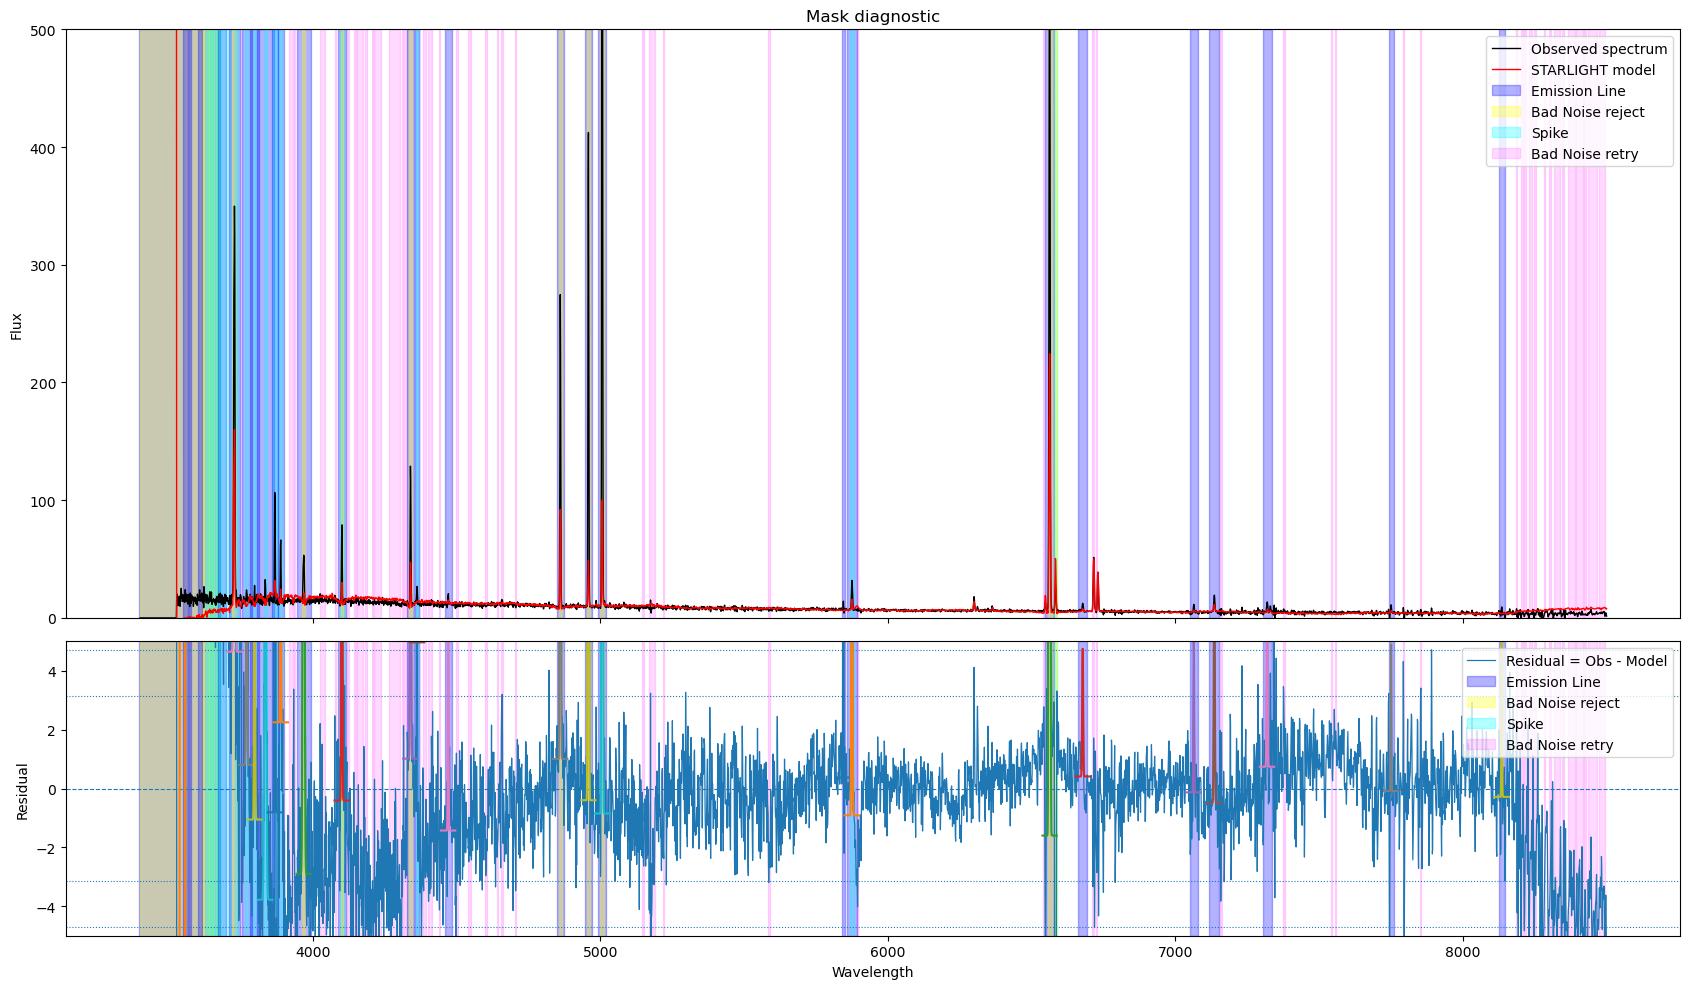

In [3]:

DF_snr = pd.read_csv('/home/holman/HIIGalaxies/Spectral_synthesis/HIIGsample_data.csv')
spec_list = [f for f in os.listdir('/home/holman/Data_storageHII/HIIG_specDR17/') if f.endswith('.fits')]

mask_PATH = '/home/holman/StarLightv05/Starlight_masks/'

#O_o = 77

for O_o in range(1): #len(spec_list)):

    print(spec_list[O_o])
    hdu = fits.open('/home/holman/Data_storageHII/HIIG_specDR17/'+ spec_list[O_o])
    plate,mjd,fiberid = spec_list[O_o][5:9],spec_list[O_o][10:15],spec_list[O_o][16:20]
    print(plate,mjd,fiberid)
    ID = DF_snr[(DF_snr['PLATE']==int(plate)) & (DF_snr['MJD']==int(mjd)) & (DF_snr['FIBERID']==int(fiberid))]['TAB5_INDEX'].iloc[0]
    ZZ = DF_snr[(DF_snr['PLATE']==int(plate)) & (DF_snr['MJD']==int(mjd)) & (DF_snr['FIBERID']==int(fiberid))]['Z'].iloc[0]
    RA = DF_snr[(DF_snr['PLATE']==int(plate)) & (DF_snr['MJD']==int(mjd)) & (DF_snr['FIBERID']==int(fiberid))]['RA'].iloc[0]
    DEC = DF_snr[(DF_snr['PLATE']==int(plate)) & (DF_snr['MJD']==int(mjd)) & (DF_snr['FIBERID']==int(fiberid))]['DEC'].iloc[0]
    print(ID,ZZ,RA,DEC)

    c = SkyCoord(ra=RA*u.degree, dec=DEC*u.degree, frame='icrs')
    c.galactic

    sfd = SFDQuery()
    ebv01 = sfd(c.galactic)
    tab = Table.read(hdu[1])
    lambda01 = 10**tab['loglam']
    waveobs = lambda01 / (1.0 + 2.735182E-4 + 131.4182 / lambda01**2 + 2.76249E8 / lambda01**4)
    wave = waveobs/(1.0+ZZ)
    fluxUnred = pyasl.unred(wave, tab['flux'], ebv=ebv01, R_V=3.1)
    flux_final = fluxUnred*(1.0+ZZ)**3
    wave_in = int(wave[2])             #initial wavelength
    wave_fin = int(wave[len(wave)-2])  #final wavelength
    wave_new = np.arange(wave_in, wave_fin, 1)
    flux_interpolate = interp1d(wave, flux_final, kind='quadratic')
    flux_starlight = flux_interpolate(wave_new)
    fluxUnred_M = pyasl.unred(wave, tab['model'], ebv=ebv01, R_V=3.1)
    flux_final_M = fluxUnred_M*(1.0+ZZ)**3
    flux_interpolate_M = interp1d(wave, flux_final_M, kind='quadratic')
    flux_starlight_M = flux_interpolate_M(wave_new)

    lambda_nuevo = np.arange(3400, 8501, 1)
    flujo_nuevo = np.zeros_like(lambda_nuevo, dtype=float)
    flujo_nuevo_M = np.ones_like(lambda_nuevo, dtype=float) *1000

    mascara_nuevo = (lambda_nuevo >= wave_new.min()) & (lambda_nuevo <= wave_new.max())
    mascara_orig = (wave_new >= lambda_nuevo.min()) & (wave_new <= lambda_nuevo.max())

    flujo_nuevo[mascara_nuevo] = flux_starlight[mascara_orig]
    flujo_nuevo_M[mascara_nuevo] = flux_starlight_M[mascara_orig]

    Lambda_sdss = lambda_nuevo
    Observed_FLUX = flujo_nuevo
    Modeled_FLUX = flujo_nuevo_M

    result = build_starlight_mask_records(
        Lambda_sdss, Observed_FLUX, Modeled_FLUX,
        emission_kwargs=dict(snr_peak=2.0, prominence_sigma=3.0, mask_nsigma=10.0),
        spike_kwargs=dict(spike_sigma=7.0, max_width_pix=5, grow_pix=5),
        hard_bad_kwargs=dict(hard_sigma=5.0, min_bad_run_pix=5, grow_pix=2),
        soft_bad_kwargs=dict(soft_sigma_low=1.0, soft_sigma_high=3.0, min_run_pix=4, grow_pix=1),
        merge_padding_angstrom=3.0,
    )

    if len(str(ID)) < 3 and len(str(ID)) > 2:
        ID = '00' + str(ID)
    if len(str(ID)) < 2 and len(str(ID)) > 1:
        ID = '0' + str(ID)


    save_mask_crap_format(f"{mask_PATH}Mask_{ID}.SDSS.MILES45.txt", result["records"])
    plot_mask_diagnostics(Lambda_sdss, Observed_FLUX, Modeled_FLUX, result, title="Mask diagnostic",
                            save_path=f"{mask_PATH}Mask_{ID}.SDSS.MILES45.png")




No distance provided, no distance dependent calculations available. Distances have to be measured in u.Mpc, redshift as plain number.
STARLIGHT .out file sucessfuly transformed to .fits format. Location: /home/holman/StarLightv05/outputs/prefit2/006.CAL.MILES45.fits
No distance provided, no distance dependent calculations available. Distances have to be measured in u.Mpc, redshift as plain number.
STARLIGHT .out file sucessfuly transformed to .fits format. Location: /home/holman/StarLightv05/outputs/prefit2/006.GD1.MILES45.fits
No distance provided, no distance dependent calculations available. Distances have to be measured in u.Mpc, redshift as plain number.
STARLIGHT .out file sucessfuly transformed to .fits format. Location: /home/holman/StarLightv05/outputs/prefit2/006.GD2.MILES45.fits
No distance provided, no distance dependent calculations available. Distances have to be measured in u.Mpc, redshift as plain number.
STARLIGHT .out file sucessfuly transformed to .fits format. Locat

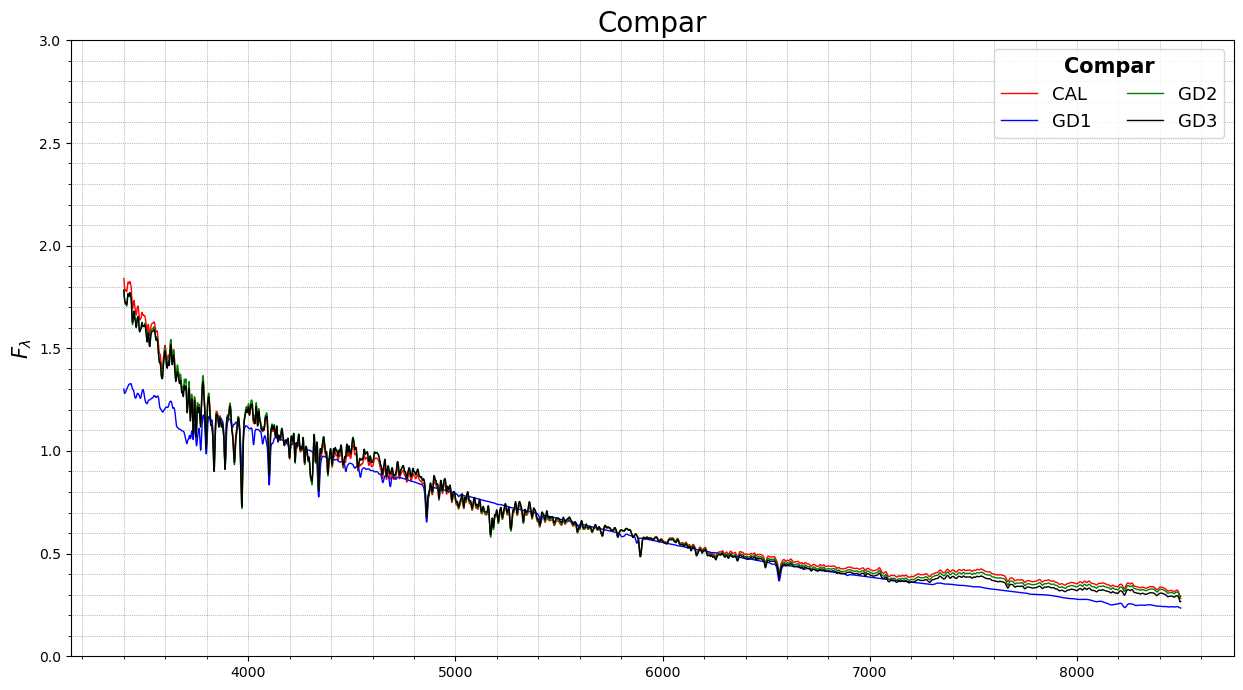

In [11]:
spec1 = farsight.Starlight(home = '/home/holman/StarLightv05/outputs/prefit2/', file ='006.CAL.MILES45.out')
spec2 = farsight.Starlight(home = '/home/holman/StarLightv05/outputs/prefit2/', file ='006.GD1.MILES45.out')
spec3 = farsight.Starlight(home = '/home/holman/StarLightv05/outputs/prefit2/', file ='006.GD2.MILES45.out')
spec4 = farsight.Starlight(home = '/home/holman/StarLightv05/outputs/prefit2/', file ='006.GD3.MILES45.out')

fig, ax_t = plt.subplots(figsize=(15, 8))
spec1.BestFitSpectrum(ax=ax_t,label='CAL',color='red'   , linewidth = 1.0)
spec2.BestFitSpectrum(ax=ax_t,label='GD1',color='blue'   , linewidth = 1.0)
spec3.BestFitSpectrum(ax=ax_t,label='GD2',color='green'   , linewidth = 1.0)
spec4.BestFitSpectrum(ax=ax_t,label='GD3',color='black'   , linewidth = 1.0)
ax_t.minorticks_on()
ax_t.tick_params(axis='x',which='major',labelbottom='off')
ax_t.set_ylim(0,3.0)
ax_t.set_title('Compar',fontsize=20)
ax_t.legend(loc='upper right',ncol=2, title = 'Compar', fontsize=13,title_fontproperties = {'weight':'bold', "size":15})
ax_t.set_ylabel(r'$F_\lambda$', fontsize=15)
ax_t.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)

In [43]:
from pathlib import Path


def parse_mask_file(filename):
    """
    Lee un archivo de máscaras tipo STARLIGHT/Mask_CRAP.
    
    Formato esperado:
    primera línea: número de máscaras
    resto:
    lambda_min lambda_max weight comment1 comment2...
    
    Devuelve una lista de diccionarios.
    """
    records = []

    with open(filename, "r", encoding="utf-8") as f:
        lines = [line.rstrip("\n") for line in f if line.strip()]

    if not lines:
        raise ValueError(f"El archivo {filename} está vacío.")

    # La primera línea debe ser el número de máscaras
    try:
        n_masks_declared = int(lines[0].split()[0])
    except Exception as e:
        raise ValueError(
            f"No se pudo interpretar la primera línea de {filename} como número de máscaras."
        ) from e

    for i, line in enumerate(lines[1:], start=2):
        parts = line.split()

        if len(parts) < 4:
            raise ValueError(
                f"Línea mal formada en {filename}, línea {i}: '{line}'"
            )

        try:
            lam_min = float(parts[0])
            lam_max = float(parts[1])
            weight = float(parts[2])
        except Exception as e:
            raise ValueError(
                f"No se pudieron leer lambda_min/lambda_max/weight en {filename}, línea {i}: '{line}'"
            ) from e

        comment1 = parts[3]
        comment2 = " ".join(parts[4:]) if len(parts) > 4 else ""

        records.append({
            "lambda_min": lam_min,
            "lambda_max": lam_max,
            "weight": weight,
            "comment1": comment1,
            "comment2": comment2,
        })

    if n_masks_declared != len(records):
        print(
            f"Advertencia: {filename} declara {n_masks_declared} máscaras, "
            f"pero se leyeron {len(records)}."
        )

    return records


def clip_record_to_region(record, region_min=None, region_max=None):
    """
    Recorta una máscara a una región [region_min, region_max].
    Si no intersecta la región, devuelve None.
    """
    lo = record["lambda_min"]
    hi = record["lambda_max"]

    if region_min is not None:
        lo = max(lo, region_min)
    if region_max is not None:
        hi = min(hi, region_max)

    if lo >= hi:
        return None

    new_record = record.copy()
    new_record["lambda_min"] = lo
    new_record["lambda_max"] = hi
    return new_record


def merge_mask_files_by_lambda(file_a, file_b, output_file, split_lambda=4000.0):
    """
    Combina dos archivos de máscara:
    - toma del archivo A las máscaras en lambda < split_lambda
    - toma del archivo B las máscaras en lambda > split_lambda
    
    Si una máscara cruza split_lambda, la recorta.
    """
    records_a = parse_mask_file(file_a)
    records_b = parse_mask_file(file_b)

    merged = []

    # Tomar de A todo lo que quede por debajo del corte
    for rec in records_a:
        clipped = clip_record_to_region(rec, region_min=None, region_max=split_lambda)
        if clipped is not None:
            merged.append(clipped)

    # Tomar de B todo lo que quede por encima del corte
    for rec in records_b:
        clipped = clip_record_to_region(rec, region_min=split_lambda, region_max=None)
        if clipped is not None:
            merged.append(clipped)

    # Ordenar por lambda_min
    merged.sort(key=lambda r: (r["lambda_min"], r["lambda_max"]))

    # Escribir archivo final
    with open(output_file, "w", encoding="utf-8") as f:
        f.write(f"{len(merged)}\n")
        for rec in merged:
            f.write(
                f"{rec['lambda_min']:.1f}  "
                f"{rec['lambda_max']:.1f}  "
                f"{rec['weight']:.1f}  "
                f"{rec['comment1']:<12s} "
                f"{rec['comment2']}\n"
            )

    print(f"Archivo combinado guardado en: {output_file}")
    print(f"Número total de máscaras: {len(merged)}")


In [44]:
sdss_mask_list = [f for f in os.listdir('/home/holman/StarLightv05/Starlight_masks') if f.endswith('.txt')]
sdss_mask_list.sort()
print(len(sdss_mask_list))
sdss_mask_list

121


['Mask_001.SDSS.MILES45.txt',
 'Mask_002.SDSS.MILES45.txt',
 'Mask_003.SDSS.MILES45.txt',
 'Mask_004.SDSS.MILES45.txt',
 'Mask_005.SDSS.MILES45.txt',
 'Mask_006.SDSS.MILES45.txt',
 'Mask_007.SDSS.MILES45.txt',
 'Mask_008.SDSS.MILES45.txt',
 'Mask_009.SDSS.MILES45.txt',
 'Mask_010.SDSS.MILES45.txt',
 'Mask_011.SDSS.MILES45.txt',
 'Mask_012.SDSS.MILES45.txt',
 'Mask_013.SDSS.MILES45.txt',
 'Mask_014.SDSS.MILES45.txt',
 'Mask_015.SDSS.MILES45.txt',
 'Mask_016.SDSS.MILES45.txt',
 'Mask_017.SDSS.MILES45.txt',
 'Mask_018.SDSS.MILES45.txt',
 'Mask_019.SDSS.MILES45.txt',
 'Mask_020.SDSS.MILES45.txt',
 'Mask_023.SDSS.MILES45.txt',
 'Mask_024.SDSS.MILES45.txt',
 'Mask_025.SDSS.MILES45.txt',
 'Mask_026.SDSS.MILES45.txt',
 'Mask_027.SDSS.MILES45.txt',
 'Mask_028.SDSS.MILES45.txt',
 'Mask_029.SDSS.MILES45.txt',
 'Mask_030.SDSS.MILES45.txt',
 'Mask_031.SDSS.MILES45.txt',
 'Mask_032.SDSS.MILES45.txt',
 'Mask_033.SDSS.MILES45.txt',
 'Mask_034.SDSS.MILES45.txt',
 'Mask_035.SDSS.MILES45.txt',
 'Mask_036

In [45]:
star_mask_list = [f for f in os.listdir('/home/holman/HIIGalaxies/Spectral_synthesis/STARLIGHT/prefit_masks/') if f.endswith('.txt')]
#star_mask_list = [item for item in star_mask_list if 'CAL' in item]
star_mask_list.sort()
print(len(star_mask_list))
star_mask_list

121


['mask_001.txt',
 'mask_002.txt',
 'mask_003.txt',
 'mask_004.txt',
 'mask_005.txt',
 'mask_006.txt',
 'mask_007.txt',
 'mask_008.txt',
 'mask_009.txt',
 'mask_010.txt',
 'mask_011.txt',
 'mask_012.txt',
 'mask_013.txt',
 'mask_014.txt',
 'mask_015.txt',
 'mask_016.txt',
 'mask_017.txt',
 'mask_018.txt',
 'mask_019.txt',
 'mask_020.txt',
 'mask_023.txt',
 'mask_024.txt',
 'mask_025.txt',
 'mask_026.txt',
 'mask_027.txt',
 'mask_028.txt',
 'mask_029.txt',
 'mask_030.txt',
 'mask_031.txt',
 'mask_032.txt',
 'mask_033.txt',
 'mask_034.txt',
 'mask_035.txt',
 'mask_036.txt',
 'mask_037.txt',
 'mask_038.txt',
 'mask_039.txt',
 'mask_040.txt',
 'mask_041.txt',
 'mask_042.txt',
 'mask_043.txt',
 'mask_044.txt',
 'mask_045.txt',
 'mask_046.txt',
 'mask_047.txt',
 'mask_048.txt',
 'mask_049.txt',
 'mask_050.txt',
 'mask_051.txt',
 'mask_052.txt',
 'mask_053.txt',
 'mask_054.txt',
 'mask_055.txt',
 'mask_056.txt',
 'mask_057.txt',
 'mask_058.txt',
 'mask_059.txt',
 'mask_060.txt',
 'mask_061.txt

In [46]:
final_mask_list = [(lambda x: 'BestMask_' + x.split('_')[1])(x) for x in star_mask_list]
#final_mask_list.sort()
print(len(final_mask_list))
final_mask_list

121


['BestMask_001.txt',
 'BestMask_002.txt',
 'BestMask_003.txt',
 'BestMask_004.txt',
 'BestMask_005.txt',
 'BestMask_006.txt',
 'BestMask_007.txt',
 'BestMask_008.txt',
 'BestMask_009.txt',
 'BestMask_010.txt',
 'BestMask_011.txt',
 'BestMask_012.txt',
 'BestMask_013.txt',
 'BestMask_014.txt',
 'BestMask_015.txt',
 'BestMask_016.txt',
 'BestMask_017.txt',
 'BestMask_018.txt',
 'BestMask_019.txt',
 'BestMask_020.txt',
 'BestMask_023.txt',
 'BestMask_024.txt',
 'BestMask_025.txt',
 'BestMask_026.txt',
 'BestMask_027.txt',
 'BestMask_028.txt',
 'BestMask_029.txt',
 'BestMask_030.txt',
 'BestMask_031.txt',
 'BestMask_032.txt',
 'BestMask_033.txt',
 'BestMask_034.txt',
 'BestMask_035.txt',
 'BestMask_036.txt',
 'BestMask_037.txt',
 'BestMask_038.txt',
 'BestMask_039.txt',
 'BestMask_040.txt',
 'BestMask_041.txt',
 'BestMask_042.txt',
 'BestMask_043.txt',
 'BestMask_044.txt',
 'BestMask_045.txt',
 'BestMask_046.txt',
 'BestMask_047.txt',
 'BestMask_048.txt',
 'BestMask_049.txt',
 'BestMask_05

In [50]:
def total_mask_merger(file_sdss,file_starprefit,final_mask,lambda_cut = 4000.0):
    paths = ['/home/holman/StarLightv05/Starlight_masks/','/home/holman/HIIGalaxies/Spectral_synthesis/STARLIGHT/prefit_masks/','/home/holman/HIIGalaxies/Spectral_synthesis/STARLIGHT/merged_masks/']

    merge_mask_files_by_lambda(file_a = f'{paths[0]}{file_sdss}',
                                file_b = f'{paths[1]}{file_starprefit}',
                                output_file = f'{paths[2]}{final_mask}',
                                split_lambda=lambda_cut)
    return 0

tmp = Parallel(n_jobs=-1)(
    delayed(total_mask_merger)(a, b, c) 
    for a, b, c in zip(sdss_mask_list, star_mask_list, final_mask_list)
)

print(tmp)




Archivo combinado guardado en: /home/holman/HIIGalaxies/Spectral_synthesis/STARLIGHT/merged_masks/BestMask_001.txt
Número total de máscaras: 92
Archivo combinado guardado en: /home/holman/HIIGalaxies/Spectral_synthesis/STARLIGHT/merged_masks/BestMask_002.txt
Número total de máscaras: 54
Archivo combinado guardado en: /home/holman/HIIGalaxies/Spectral_synthesis/STARLIGHT/merged_masks/BestMask_003.txt
Número total de máscaras: 103
Archivo combinado guardado en: /home/holman/HIIGalaxies/Spectral_synthesis/STARLIGHT/merged_masks/BestMask_004.txt
Número total de máscaras: 48
Archivo combinado guardado en: /home/holman/HIIGalaxies/Spectral_synthesis/STARLIGHT/merged_masks/BestMask_005.txt
Número total de máscaras: 50
Archivo combinado guardado en: /home/holman/HIIGalaxies/Spectral_synthesis/STARLIGHT/merged_masks/BestMask_006.txt
Número total de máscaras: 94
Archivo combinado guardado en: /home/holman/HIIGalaxies/Spectral_synthesis/STARLIGHT/merged_masks/BestMask_007.txt
Número total de másc